# Предсказание выживаемости персонажей «Игры престолов»

Бинарная классификация: по данным о персонажах из [A Wiki of Ice and Fire](http://awoiaf.westeros.org/) нужно предсказать, жив ли персонаж (`isAlive`).

- **Данные:** 1557 персонажей в обучающей выборке и 389 в тестовой
- **Подход:** предобработка в pandas (кодирование пропусков, группировка категорий, one-hot), сравнение `LogisticRegression` и `RandomForestClassifier`
- **Результат:** `RandomForest` — accuracy 0.8237 на валидации (доля живых в train — 0.7784) и 0.7326 на скрытом тесте

Учебный проект курса Школы глубокого обучения ФПМИ МФТИ.

## Данные

Целевая переменная — `isAlive`. Признаки: пол (`male`), титул (`title`), дом (`house`), культура (`culture`), появление в книгах 1–5 (`book1`–`book5`), знатность (`isNoble`), семейное положение (`isMarried`), возраст (`age`), год рождения (`dateOfBirth`), имена родственников (`mother`, `father`, `heir`, `spouse`) и жив ли каждый из них (`isAlive*`), число умерших родственников (`numDeadRelations`), популярность (`popularity`).

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

In [3]:
data = pd.read_csv('game_of_thrones_train.csv', index_col='S.No')

## Первичный анализ

Типы данных, базовые статистики и пропуски.

In [4]:
data.describe(include = 'object').T

,count,unique,top,freq
name,1557,1557,Melara Hetherspoon,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


In [5]:
data.describe(include = ['number']).T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


In [6]:
data.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


Пропусков много: в `mother`, `father`, `heir` и соответствующих `isAlive*` отсутствует более 98% значений, в `age` и `dateOfBirth` — 82%. Строки с пропусками не удаляем — выборка сократилась бы почти полностью, — поэтому информацию о пропуске кодируем отдельными признаками.

## Числовые признаки

`popularity` сильно скошен вправо: большинство значений близки к нулю. Ниже — исходное распределение и логарифм `log10(100·x + 1)` (только для визуализации, в модель идёт исходный признак).

<Axes: >

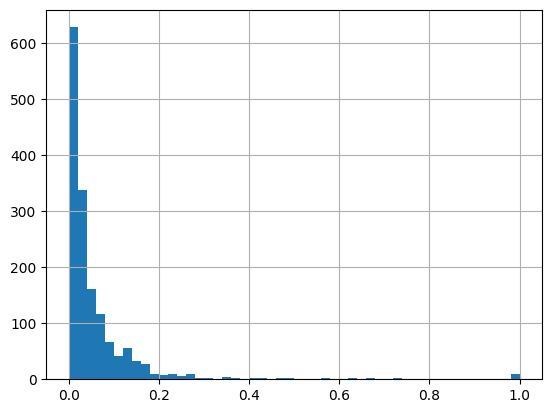

In [7]:
data.popularity.hist(bins=50)

<Axes: >

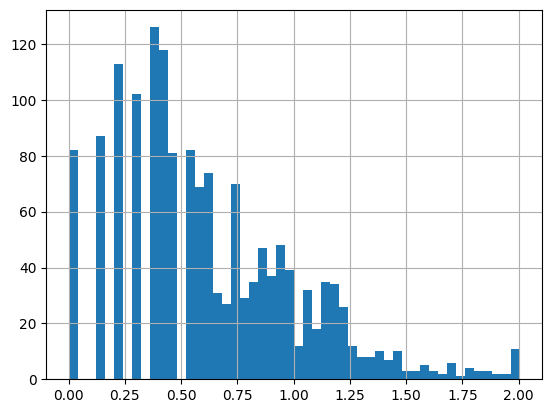

In [8]:
np.log10(data["popularity"]*100+1).hist(bins=50)

`numDeadRelations` упрощаем до бинарного признака (есть ли умершие родственники), а `age` раскладываем на значение (пропуск → 0) и флаг отсутствия данных `age_no_data`.

In [9]:
data['boolDeadRelations'] = data.numDeadRelations > 0

In [10]:
data['age_value'] = [age if pd.isna(age)==0 else 0 for age in data['age']]
data['age_no_data'] = [1 if pd.isna(x) else 0 for x in data['age']]

## Категориальные признаки: culture

`culture` встречается в 51 варианте написания (разный регистр, синонимы), а у 1069 из 1557 персонажей пропущена. Сводим варианты к 11 укрупнённым группам по словарю, пропуски выделяем в отдельную категорию `culture_no_data`.

In [11]:
data['culture'].value_counts(dropna=False)

,count
culture,
NaN,1069
Northmen,94
Ironborn,91
Free Folk,45
Braavosi,39
Valyrian,28
Ghiscari,17
Dornish,17
Dothraki,17


In [12]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

In [13]:
# инвертируем словарь: название народа → укрупнённая группа
cultures_grouped_inverted = {}
for key in cultures_grouped:
  for val in cultures_grouped[key]:
    cultures_grouped_inverted.update({val:key})
cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Общая статистика: среднее `isAlive` = 0.778 — это доля живых в обучающей выборке. Такую accuracy дала бы модель, которая всегда отвечает «жив»; это ориентир для оценки моделей ниже.

In [14]:
data.describe()

,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,age_value,age_no_data
count,1557.000000,279.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000,18.000000,22.000000,21.000000,200.00000,1557.000000,1557.000000,279.000000,1557.000000,1557.000000,1557.000000,1557.000000,1557.000000
mean,0.590880,247.551971,0.138728,0.327553,0.431599,0.562620,0.330122,0.666667,0.227273,0.666667,0.79000,0.128452,0.439306,35.290323,0.187540,0.062400,0.778420,6.323699,0.820809
std,0.491829,61.550441,0.345774,0.469472,0.495458,0.496223,0.470408,0.485071,0.428932,0.483046,0.40833,0.334700,0.496462,26.364864,1.114648,0.121416,0.415443,17.535217,0.383635
min,0.000000,-25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,241.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,16.000000,0.000000,0.013378,1.000000,0.000000,1.000000
50%,1.000000,272.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.00000,0.000000,0.000000,24.000000,0.000000,0.023411,1.000000,0.000000,1.000000
75%,1.000000,286.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.00000,0.000000,1.000000,49.000000,0.000000,0.063545,1.000000,0.000000,1.000000
max,1.000000,299.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,100.000000,15.000000,1.000000,1.000000,100.000000,1.000000


In [15]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

In [16]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

In [17]:
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isMarried,isNoble,age,numDeadRelations,popularity,isAlive,boolDeadRelations,age_value,age_no_data,culture_grouped
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,0,0,NaN,11,0.605351,0,True,0.0,1,culture_no_data
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,1,1,97.0,1,0.896321,1,True,97.0,0,the Isles and Rivers
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,0,1,NaN,0,0.267559,1,False,0.0,1,culture_no_data
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,1,1,23.0,0,0.183946,0,False,23.0,0,culture_no_data
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,1,1,29.0,0,0.043478,1,False,29.0,0,Dorne


In [18]:
# исходные столбцы больше не нужны: вместо них созданы age_value/age_no_data, culture_grouped и boolDeadRelations
data.drop(columns=['age','culture','numDeadRelations'],inplace=True)

## Бинарные и категориальные признаки

Смотрим число уникальных значений: признаки с двумя значениями бинарные, остальные (`title`, `house`, `culture`, имена) требуют кодирования.

In [19]:
# количество уникальных значений в каждом столбце
data.nunique()

,0
name,1557
title,195
male,2
dateOfBirth,105
mother,16
father,19
heir,20
house,315
spouse,186
book1,2


## Статус родственников (`isAlive*`)

Статус супруга, отца, матери и наследника известен лишь у 200, 22, 18 и 21 персонажа соответственно. Выживаемость у них заметно различается: например, если наследник мёртв — 0.00 (7 персонажей), если жив — 0.36 (14 персонажей), а если данных нет — 0.79.

In [20]:
# доля выживших в зависимости от статуса супруга (NaN — супруг не указан)
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveSpouse', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveSpouse,,
0.0,0.619048,42
1.0,0.753165,158
NaN,0.786293,1357


In [21]:
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveHeir', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveHeir,,
0.0,0.000000,7
1.0,0.357143,14
NaN,0.785807,1536


In [22]:
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveFather', aggfunc=['mean', 'count'], dropna=False)

,mean,count
,isAlive,isAlive
isAliveFather,,
0.0,0.235294,17
1.0,0.400000,5
NaN,0.785668,1535


In [23]:
pd.pivot_table(data = data, values = 'isAlive', index = 'isAliveMother', aggfunc=['mean', 'count'], dropna=False)
# доля выживших одинакова при isAliveMother = 0 и 1 (0.1667), но выборка маленькая (6 и 12 наблюдений);
# поэтому дальше кодируем только факт наличия данных

,mean,count
,isAlive,isAlive
isAliveMother,,
0.0,0.166667,6
1.0,0.166667,12
NaN,0.785575,1539


In [24]:
data[['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']].isna().sum()
# пропусков очень много (более 87% во всех четырёх признаках)

,0
isAliveMother,1539
isAliveFather,1535
isAliveHeir,1536
isAliveSpouse,1357


Значение и факт его отсутствия несут разную информацию, поэтому для `isAliveSpouse`, `isAliveFather`, `isAliveHeir` создаём два признака: значение (пропуск → 0) и флаг `_no_data`. Для `isAliveMother` доля выживших при значениях 0 и 1 одинакова (0.1667, выборка очень мала), поэтому оставляем только флаг.

In [25]:
# isAliveSpouse / Father / Heir: значение (пропуск → 0) + флаг отсутствия данных

data['isAliveSpouse_value'] = [x if pd.isna(x)==0 else 0 for x in data['isAliveSpouse']]
data['isAliveSpouse_no_data'] = [1 if pd.isna(x) else 0 for x in data['isAliveSpouse']]

data['isAliveFather_value'] = [x if pd.isna(x)==0 else 0 for x in data['isAliveFather']]
data['isAliveFather_no_data'] = [1 if pd.isna(x) else 0 for x in data['isAliveFather']]

data['isAliveHeir_value'] = [x if pd.isna(x)==0 else 0 for x in data['isAliveHeir']]
data['isAliveHeir_no_data'] = [1 if pd.isna(x) else 0 for x in data['isAliveHeir']]

# isAliveMother: только флаг отсутствия данных
data['isAliveMother_no_data'] = data['isAliveMother'].isna()

data.drop(columns=['isAliveSpouse', 'isAliveFather', 'isAliveHeir', 'isAliveMother'], inplace=True)

## Кодирование culture, title и house

`culture` кодируем one-hot. Для `title` и `house` слишком много категорий (195 и 315): оставляем 25 самых частых значений, остальные объединяем в `other`, пропуски — в `no_data`, затем one-hot. Выживаемость заметно зависит от дома: среди домов с 30+ персонажами она варьируется от 0.30 (House Targaryen) до 0.94 (House Tyrell) — см. таблицу ниже.

In [26]:
# one-hot кодирование culture_grouped (get_dummies сам удаляет исходный столбец)

data = pd.get_dummies(data, columns=['culture_grouped'], drop_first=True)

In [27]:
# доля выживших по самым частым титулам
top_titles = data['title'].value_counts().head(25).index
data[data['title'].isin(top_titles)].groupby('title')['isAlive'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
title,,
Ser,0.774510,306
Maester,0.896552,29
Archmaester,1.000000,21
Lord,0.684211,19
Septon,0.750000,16
Winterfell,0.666667,15
Lady,0.700000,10
King in the North,1.000000,9
Princess,0.222222,9


In [28]:
# 25 самых частых титулов; остальные → title_other, пропуски → title_no_data

top_titles = data['title'].value_counts().head(25).index

data['title_grouped'] = data['title'].apply(
    lambda x: x if x in top_titles else ('title_no_data' if pd.isna(x) else 'title_other'))

# one-hot кодирование и удаление исходного столбца
data = pd.get_dummies(data, columns=['title_grouped'], drop_first=True)
data.drop(columns=['title'], inplace=True)

In [29]:
# доля выживших по самым частым домам (топ-20)
top_houses = data['house'].value_counts().head(20).index
data[data['house'].isin(top_houses)].groupby('house')['isAlive'].agg(['mean', 'count']).sort_values('count', ascending=False)

,mean,count
house,,
House Frey,0.898876,89
Night's Watch,0.568182,88
House Stark,0.767857,56
House Targaryen,0.300000,40
House Lannister,0.694444,36
House Tyrell,0.939394,33
House Greyjoy,0.600000,30
House Osgrey,0.750000,20
Faith of the Seven,0.866667,15


In [30]:
# 25 самых частых домов; остальные → house_other, пропуски → house_no_data
top_houses = data['house'].value_counts().head(25).index

data['house_grouped'] = data['house'].apply(
    lambda x: x if x in top_houses else ('house_no_data' if pd.isna(x) else 'house_other'))

data = pd.get_dummies(data, columns=['house_grouped'], drop_first=True)
data.drop(columns=['house'], inplace=True)

## Остальные признаки

`name` — идентификатор, а пропуски `dateOfBirth` совпадают с пропусками `age` (информация о возрасте уже закодирована), поэтому оба столбца исключаем. Имена родственников (`mother`, `father`, `heir`, `spouse`) заменяем на три категории: нет данных, известный родственник, Таргариен (у Таргариенов выживаемость ниже).

In [31]:
# name — идентификатор, признаком не является
data.drop(columns=['name'], inplace=True)

In [32]:
# пропуски dateOfBirth совпадают с age, возраст уже закодирован
data.drop(columns=['dateOfBirth'], inplace=True)

In [33]:
# родственники: нет данных / известное имя / Таргариен
# (у Таргариенов выживаемость заметно ниже)
for col in ['mother', 'father', 'heir', 'spouse']:
    data[f'{col}_grouped'] = data[col].apply(
        lambda x: 'no_data' if pd.isna(x) else ('targaryen' if 'Targaryen' in x else 'known')
    )

data[[f'{col}_grouped' for col in ['mother', 'father', 'heir', 'spouse']]].apply(pd.Series.value_counts)

,mother_grouped,father_grouped,heir_grouped,spouse_grouped
known,11,9,7,185
no_data,1539,1535,1536,1357
targaryen,7,13,14,15


In [34]:
data = pd.get_dummies(data, columns=[f'{col}_grouped' for col in ['mother', 'father', 'heir', 'spouse']], drop_first=True)
data.drop(columns=['mother', 'father', 'heir', 'spouse'], inplace=True)

In [35]:
data.columns

Index(['male', 'book1', 'book2', 'book3', 'book4', 'book5', 'isMarried',
       'isNoble', 'popularity', 'isAlive', 'boolDeadRelations', 'age_value',
       'age_no_data', 'isAliveSpouse_value', 'isAliveSpouse_no_data',
       'isAliveFather_value', 'isAliveFather_no_data', 'isAliveHeir_value',
       'isAliveHeir_no_data', 'isAliveMother_no_data',
       'culture_grouped_Essos Nations', 'culture_grouped_Old Nations',
       'culture_grouped_Other Nations', 'culture_grouped_culture_no_data',
       'culture_grouped_the Iron Islands',
       'culture_grouped_the Isles and Rivers',
       'culture_grouped_the Mountain and the Vale',
       'culture_grouped_the North', 'culture_grouped_the Reach',
       'culture_grouped_the Rock', 'culture_grouped_the Stormlands',
       'title_grouped_Bitterbridge', 'title_grouped_Casterly Rock',
       'title_grouped_Cupbearer', 'title_grouped_Eyrie',
       'title_grouped_Grand Maester', 'title_grouped_Khal',
       'title_grouped_King in the North', 

In [36]:
data.isna().sum().sum()

np.int64(0)

## Связь признаков с целевой переменной

Корреляция всех признаков с `isAlive`. Сильнее всего отрицательно связаны `popularity` (−0.19), `house_grouped_House Targaryen` (−0.19), `age_value` (−0.18), `heir_grouped_targaryen` (−0.18) и `boolDeadRelations` (−0.18); положительно — появление в 4-й книге (`book4`, +0.28).

In [37]:
# корреляция всех признаков с целевой переменной
data.corr(numeric_only=True)['isAlive'].sort_values()

,isAlive
popularity,-0.194187
house_grouped_House Targaryen,-0.187057
age_value,-0.181938
heir_grouped_targaryen,-0.178535
boolDeadRelations,-0.178177
...,...
isAliveHeir_no_data,0.152124
isAliveMother_no_data,0.159302
mother_grouped_no_data,0.159302
book4,0.284014


## Обучение моделей

Отделяем 20% данных на валидацию и сравниваем две модели.

In [38]:
y = data['isAlive']
X = data.drop(columns=['isAlive'])

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
# random_state фиксирует разбиение, чтобы результаты разных моделей были сопоставимы
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [42]:
# сравнение двух моделей на валидационной выборке
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000),
    'RandomForest': RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"{name}: accuracy = {acc:.4f}")

LogisticRegression: accuracy = 0.7724
RandomForest: accuracy = 0.8237


`RandomForest` (0.8237) заметно лучше `LogisticRegression` (0.7724), которая находится на уровне ориентира «всегда жив» (0.7784).

## Предсказание для тестовой выборки

Тест обрабатываем теми же правилами и теми же справочниками, что и train: словарь культур и списки `top_titles` / `top_houses` посчитаны на обучающих данных. В двух строках теста (S.No 1685 и 1869) год рождения и возраст указаны некорректно — исправляем значениями из условия задачи.

In [43]:
data_test = pd.read_csv('game_of_thrones_test.csv', index_col="S.No")

In [44]:
data_test.describe().T[['min','max','count']].assign(Nans = data_test.isna().sum())

,min,max,count,Nans
male,0.0,1.0,389.0,0
dateOfBirth,-28.0,298299.0,154.0,235
book1,0.0,1.0,389.0,0
book2,0.0,1.0,389.0,0
book3,0.0,1.0,389.0,0
book4,0.0,1.0,389.0,0
book5,0.0,1.0,389.0,0
isAliveMother,1.0,1.0,3.0,386
isAliveFather,0.0,0.0,4.0,385
isAliveHeir,0.0,1.0,2.0,387


In [45]:
# некорректные значения в двух строках теста (по подсказке из условия)
data_test.loc[1685, 'dateOfBirth'] = 278.
data_test.loc[1685, 'age'] = 0.

data_test.loc[1869, 'dateOfBirth'] = 299.
data_test.loc[1869, 'age'] = 0.

In [46]:
# dateOfBirth исключён, как и в train
data_test.drop(columns='dateOfBirth', inplace= True)

In [47]:
# boolDeadRelations — как в train
data_test['boolDeadRelations'] = data_test['numDeadRelations'] > 0
data_test.drop(columns='numDeadRelations', inplace=True)

In [48]:
# age_value / age_no_data — как в train
data_test['age_value'] = [x if x>0 else 0 for x in data_test['age']]
data_test['age_no_data'] = [1 if pd.isna(x) else 0 for x in data_test['age']]

In [49]:
# исходный age больше не нужен
data_test.drop(columns='age', inplace=True)

In [50]:
# культуры — тем же словарём, что и в train
data_test['culture_grouped'] = data_test['culture'].str.lower().map(cultures_grouped_inverted)
data_test['culture_grouped'] = data_test['culture_grouped'].fillna('culture_no_data')

In [51]:
# исходный culture больше не нужен
data_test.drop(columns='culture', inplace=True)

In [52]:
# значения и флаги отсутствия данных — как в train
data_test['isAliveFather_value'] = [x if pd.isna(x)==False else 0 for x in data_test['isAliveFather']]
data_test['isAliveFather_no_data'] = [1 if pd.isna(x) else 0 for x in data_test['isAliveFather']]

data_test['isAliveHeir_value'] = [x if pd.isna(x)==False else 0 for x in data_test['isAliveHeir']]
data_test['isAliveHeir_no_data'] = [1 if pd.isna(x) else 0 for x in data_test['isAliveHeir']]

data_test['isAliveSpouse_value'] = [x if pd.isna(x)==False else 0 for x in data_test['isAliveSpouse']]
data_test['isAliveSpouse_no_data'] = [1 if pd.isna(x) else 0 for x in data_test['isAliveSpouse']]

data_test['isAliveMother_no_data'] = [1 if pd.isna(x) else 0 for x in data_test['isAliveMother']]

In [53]:
# исходные isAlive* больше не нужны
data_test.drop(columns=['isAliveSpouse', 'isAliveFather', 'isAliveHeir', 'isAliveMother'], inplace=True)

In [54]:
# title и house группируем по спискам top_titles / top_houses, посчитанным на train
data_test['title_grouped'] = [
    x if x in top_titles else ('title_no_data' if pd.isna(x) else 'title_other')
    for x in data_test['title']
]

data_test['house_grouped'] = [
    x if x in top_houses else ('house_no_data' if pd.isna(x) else 'house_other')
    for x in data_test['house']
]

In [55]:
# родственники: no_data / known / targaryen — как в train
for col in ['mother', 'father', 'heir', 'spouse']:
    data_test[f'{col}_grouped'] = data_test[col].apply(
        lambda x: 'no_data' if pd.isna(x) else ('targaryen' if 'Targaryen' in x else 'known')
    )

In [56]:
data_test.drop(columns=['name', 'title', 'house', 'mother', 'father', 'heir', 'spouse'], inplace=True)

In [57]:
data_test = pd.get_dummies(
    data_test,
    columns=['culture_grouped', 'title_grouped', 'house_grouped',
             'mother_grouped', 'father_grouped', 'heir_grouped', 'spouse_grouped'],
    drop_first=True
)

После `get_dummies` набор столбцов в тесте может отличаться от обучающего, поэтому приводим их к `X.columns`: недостающие заполняем нулями, лишние отбрасываем. Финальную модель обучаем на всей обучающей выборке.

In [58]:
# после get_dummies набор столбцов в test может отличаться от train (в том числе из-за drop_first):
# приводим столбцы к X.columns — недостающие заполняем нулями, лишние отбрасываем
data_test_final = data_test.reindex(columns=X.columns, fill_value=0)

In [59]:
# обучаем финальную модель на всех train-данных (не только X_train)
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X, y)

# предсказываем
test_predictions = best_model.predict(data_test_final)

In [60]:
# доля предсказанных «жив» в тесте (accuracy относительно константного прогноза «все живы»)
accuracy_score(test_predictions, np.ones(len(test_predictions)))

0.7223650385604113

## Файл submission

Записываем предсказания в шаблон: из 389 персонажей теста 281 предсказан живым и 108 — мёртвым.

In [61]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

In [62]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [63]:
# записываем предсказания в шаблон submission
submission['isAlive'] = test_predictions
submission.to_csv("/content/new_submission.csv", index=False)

In [64]:
submission.value_counts()

,count
isAlive,
1,281
0,108


## Итоги

- Лучшая модель — `RandomForest`: 0.8237 на валидации и 0.7326 на скрытом тесте.
- Разрыв между валидацией и тестом, вероятно, связан с оценкой по одному разбиению train/val; кросс-валидация дала бы более надёжную оценку.
- Что можно улучшить: собрать предобработку в `Pipeline` / `ColumnTransformer` с `OneHotEncoder(handle_unknown='ignore')` (не нужно вручную выравнивать столбцы), подобрать гиперпараметры, оценить precision и recall для класса «мёртв» — accuracy скрывает дисбаланс классов (около 78% живых).